### Data Loading and Initial Inspection



In [ ]:
import pandas as pd
df = pd.read_csv('/content/Q09_learner_activity.csv')
display(df.head())

,enrolment_id,course_length_weeks,quiz_score,login_frequency,progress_percent,completion_status
0,LR0001,10,58.4,24.0,74.5,Dropped
1,LR0002,8,81.9,31.0,79.4,Dropped
2,LR0003,8,68.7,28.0,62.1,Dropped
3,LR0004,10,65.6,7.0,47.1,Dropped
4,LR0005,6,57.9,14.0,47.9,Dropped


### Data Cleaning - Handling Duplicates

The instructions indicate that the dataset contains 3 intentional duplicate records. I will identify and remove these duplicate rows to ensure data integrity for further analysis.

In [ ]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows found: {len(duplicate_rows)}")

# Display the duplicate rows
if not duplicate_rows.empty:
    print("Duplicate rows:")
    display(duplicate_rows)

# Remove duplicate rows
df_cleaned = df.drop_duplicates().copy()
print(f"Number of rows after removing duplicates: {len(df_cleaned)}")

# Verify that duplicates have been removed
print(f"Number of duplicate rows after removal: {len(df_cleaned[df_cleaned.duplicated()])}")

Number of duplicate rows found: 3
Duplicate rows:


,enrolment_id,course_length_weeks,quiz_score,login_frequency,progress_percent,completion_status
120,LR0057,12,67.4,8.0,37.3,Dropped
121,LR0109,10,73.5,30.0,87.5,Completed
122,LR0036,6,80.5,22.0,86.8,Completed


Number of rows after removing duplicates: 120
Number of duplicate rows after removal: 0


### Data Cleaning - Handling Missing Values

Following the removal of duplicate records, the next step in data cleaning is to address missing values. The instructions specify that a small number of missing values were intentionally inserted. I will identify these missing values and then decide on an appropriate strategy to handle them (e.g., imputation, removal, etc.).

In [ ]:
# Export the cleaned DataFrame to a new CSV file
df_cleaned.to_csv('/content/Q09_learner_activity_cleaned.csv', index=False)
print("Cleaned data exported to '/content/Q09_learner_activity_cleaned.csv'")

Cleaned data exported to '/content/Q09_learner_activity_cleaned.csv'


In [ ]:
# Check for missing values
missing_values = df_cleaned.isnull().sum()
print("Missing values before handling:")
display(missing_values[missing_values > 0])

# Decide on a strategy to handle missing values (e.g., imputation or removal)
# For simplicity, let's fill numerical missing values with the median and categorical with the mode.
# Identify numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Impute numerical columns with median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# Verify that all missing values have been handled
print("\nMissing values after handling:")
display(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# Display a sample of the cleaned data after handling missing values
print("\nHead of DataFrame after handling missing values:")
display(df_cleaned.head())

Missing values before handling:


,0



Missing values after handling:


,0



Head of DataFrame after handling missing values:


,enrolment_id,course_length_weeks,quiz_score,login_frequency,progress_percent,completion_status
0,LR0001,10,58.4,24.0,74.5,Dropped
1,LR0002,8,81.9,31.0,79.4,Dropped
2,LR0003,8,68.7,28.0,62.1,Dropped
3,LR0004,10,65.6,7.0,47.1,Dropped
4,LR0005,6,57.9,14.0,47.9,Dropped


### Exploratory Data Analysis (EDA)

With the data now cleaned (duplicates removed and missing values handled), I will proceed with Exploratory Data Analysis (EDA). This phase will help us understand the main characteristics of the data, discover patterns, spot anomalies, and check assumptions with the help of summary statistics and graphical representations.

First, let's look at the descriptive statistics of the numerical features.

In [ ]:
# Display descriptive statistics
print("Descriptive Statistics:")
display(df_cleaned.describe())

Descriptive Statistics:


,course_length_weeks,quiz_score,login_frequency,progress_percent
count,120.000000,120.000000,120.000000,120.000000
mean,8.266667,70.755833,22.625000,72.260833
std,2.815722,14.449755,11.417819,19.073997
min,4.000000,26.000000,3.000000,27.000000
25%,6.000000,61.800000,13.000000,59.500000
50%,8.000000,69.050000,22.500000,72.900000
75%,10.000000,79.700000,33.000000,88.500000
max,12.000000,116.400000,42.000000,100.000000


### Visualizing Numerical Feature Distributions

To better understand the spread and central tendency of the numerical features, I will create histograms for `course_length_weeks`, `quiz_score`, `login_frequency`, and `progress_percent`. This will help us identify patterns, skewness, and potential outliers more clearly.

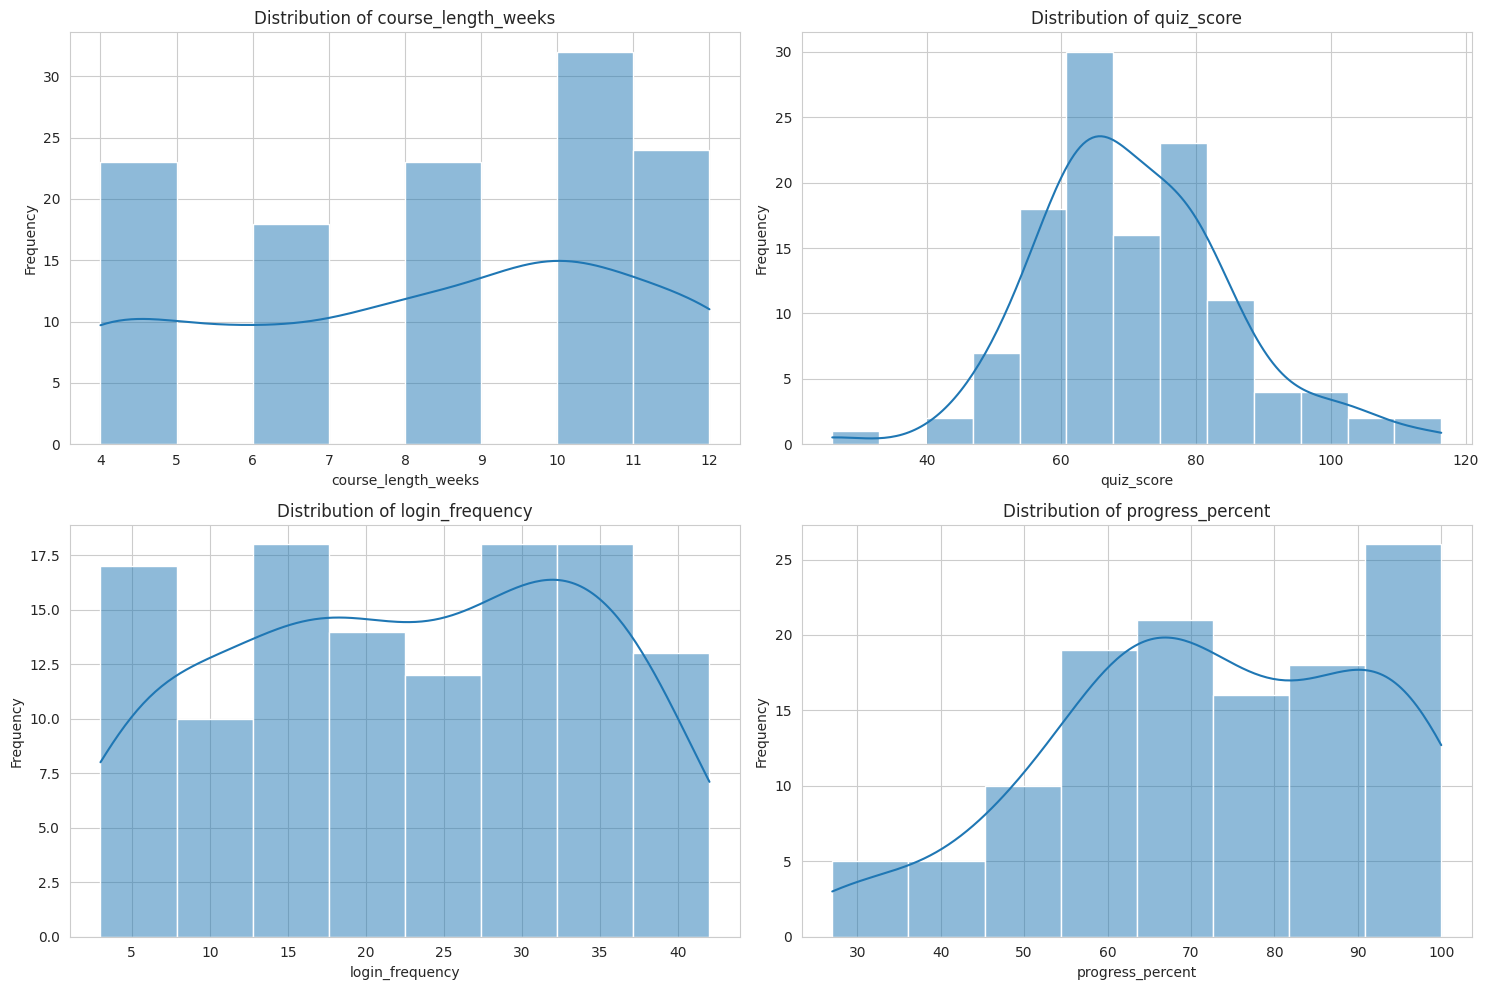

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# List of numerical columns to plot
numerical_cols = ['course_length_weeks', 'quiz_score', 'login_frequency', 'progress_percent']

# Create histograms for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Analyzing Categorical Feature: `completion_status`

To understand the distribution of learners based on their completion status, I will create a count plot for the `completion_status` column. This will show the number of learners who 'Completed', 'Dropped', or have an 'In Progress' status.

/tmp/ipykernel_2203/1901322220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='completion_status', palette='viridis')


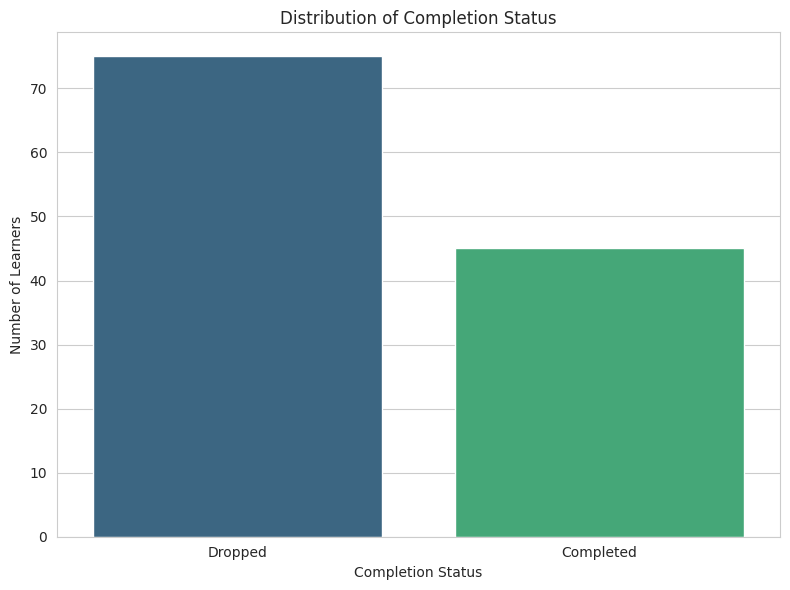


Value Counts for Completion Status:


,count
completion_status,
Dropped,75
Completed,45


In [ ]:
# Count plot for 'completion_status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='completion_status', palette='viridis')
plt.title('Distribution of Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Number of Learners')
plt.tight_layout()
plt.show()

# Display the value counts for 'completion_status'
print("\nValue Counts for Completion Status:")
display(df_cleaned['completion_status'].value_counts())

### Exploring Relationships between Numerical Features and Completion Status

To understand which numerical factors might influence a learner's `completion_status`, I will create box plots comparing the distributions of `course_length_weeks`, `quiz_score`, `login_frequency`, and `progress_percent` across the different completion statuses ('Dropped' vs. 'Completed').

/tmp/ipykernel_2203/1132664287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='completion_status', y='course_length_weeks', palette='pastel')
/tmp/ipykernel_2203/1132664287.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='completion_status', y='quiz_score', palette='pastel')
/tmp/ipykernel_2203/1132664287.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='completion_status', y='login_frequency', palette='pastel')
/tmp/ipykernel_2203/1132664287.py:26: FutureWarning: 

Passi

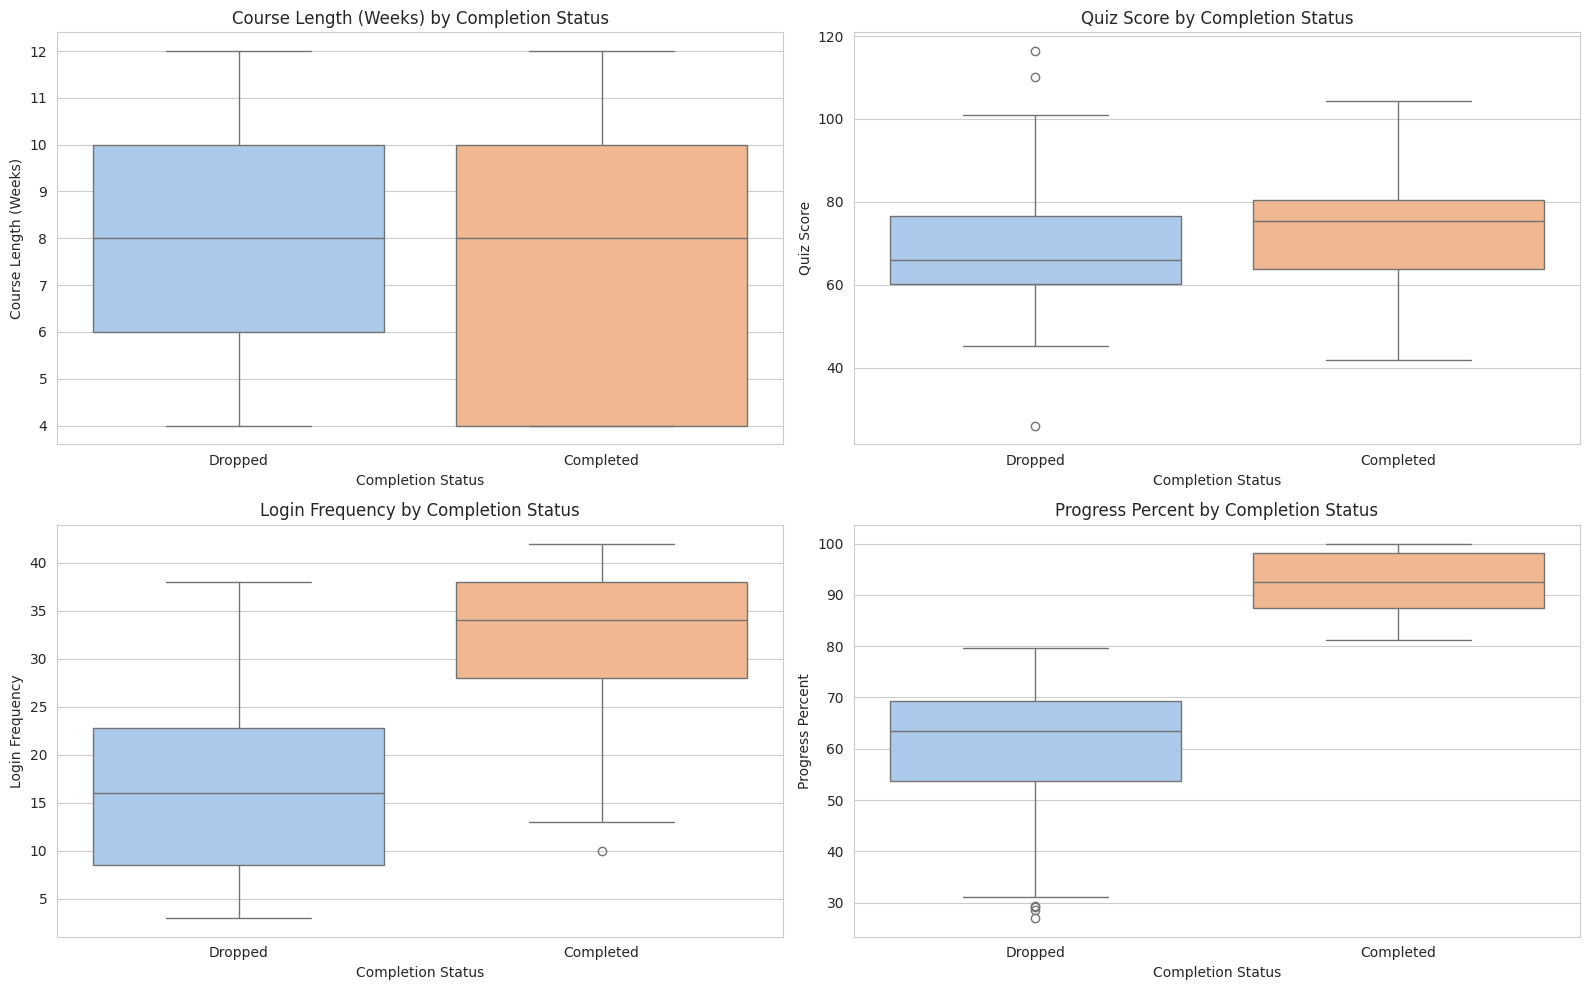

In [ ]:
plt.figure(figsize=(16, 10))

# Box plot for course_length_weeks vs completion_status
plt.subplot(2, 2, 1)
sns.boxplot(data=df_cleaned, x='completion_status', y='course_length_weeks', palette='pastel')
plt.title('Course Length (Weeks) by Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Course Length (Weeks)')

# Box plot for quiz_score vs completion_status
plt.subplot(2, 2, 2)
sns.boxplot(data=df_cleaned, x='completion_status', y='quiz_score', palette='pastel')
plt.title('Quiz Score by Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Quiz Score')

# Box plot for login_frequency vs completion_status
plt.subplot(2, 2, 3)
sns.boxplot(data=df_cleaned, x='completion_status', y='login_frequency', palette='pastel')
plt.title('Login Frequency by Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Login Frequency')

# Box plot for progress_percent vs completion_status
plt.subplot(2, 2, 4)
sns.boxplot(data=df_cleaned, x='completion_status', y='progress_percent', palette='pastel')
plt.title('Progress Percent by Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Progress Percent')

plt.tight_layout()
plt.show()

### Feature Engineering

Now that we've completed our initial EDA, we'll perform feature engineering to create new variables that might improve the predictive power of our models and provide deeper insights. This will involve:

1.  **Binarizing `completion_status`**: Transforming the categorical `completion_status` into a numerical binary target variable (`is_completed`).
2.  **Categorizing `quiz_score`**: Grouping quiz scores into distinct categories (e.g., 'Low', 'Medium', 'High').
3.  **Categorizing `login_frequency`**: Grouping login frequencies into distinct categories.
4.  **Creating an interaction term**: Combining `quiz_score` and `login_frequency` to see if their combined effect is significant.

In [ ]:
# 1. Binarize 'completion_status'
df_engineered = df_cleaned.copy()
df_engineered['is_completed'] = df_engineered['completion_status'].apply(lambda x: 1 if x == 'Completed' else 0)

# 2. Categorize 'quiz_score'
df_engineered['quiz_score_category'] = pd.cut(df_engineered['quiz_score'],
                                              bins=[0, 60, 80, 100, float('inf')],
                                              labels=['Low', 'Medium', 'High', 'Extra_High'],
                                              right=False)

# 3. Categorize 'login_frequency'
df_engineered['login_frequency_category'] = pd.cut(df_engineered['login_frequency'],
                                                   bins=[0, 10, 25, float('inf')],
                                                   labels=['Low', 'Medium', 'High'],
                                                   right=False)

# 4. Create an interaction term
df_engineered['quiz_login_interaction'] = df_engineered['quiz_score'] * df_engineered['login_frequency']

print("DataFrame with engineered features:")
display(df_engineered.head())

DataFrame with engineered features:


,enrolment_id,course_length_weeks,quiz_score,login_frequency,progress_percent,completion_status,is_completed,quiz_score_category,login_frequency_category,quiz_login_interaction
0,LR0001,10,58.4,24.0,74.5,Dropped,0,Low,Medium,1401.6
1,LR0002,8,81.9,31.0,79.4,Dropped,0,High,High,2538.9
2,LR0003,8,68.7,28.0,62.1,Dropped,0,Medium,High,1923.6
3,LR0004,10,65.6,7.0,47.1,Dropped,0,Medium,Low,459.2
4,LR0005,6,57.9,14.0,47.9,Dropped,0,Low,Medium,810.6


#Statistical Analysis

In [ ]:

# Define the dependent variable
Y = df_engineered['is_completed']

# Define the independent variables, removing 'progress_percent' due to potential perfect multicollinearity/separation
X = df_engineered[['course_length_weeks', 'quiz_score', 'login_frequency', 'quiz_login_interaction']]

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Fit the Logistic Regression model
logistic_model = sm.Logit(Y, X)
result = logistic_model.fit()

# Display the model summary
print("\nLogistic Regression Model Summary:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.340861
         Iterations 8

Logistic Regression Model Summary:
                           Logit Regression Results                           
Dep. Variable:           is_completed   No. Observations:                  120
Model:                          Logit   Df Residuals:                      115
Method:                           MLE   Df Model:                            4
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                  0.4848
Time:                        08:37:03   Log-Likelihood:                -40.903
converged:                       True   LL-Null:                       -79.388
Covariance Type:            nonrobust   LLR p-value:                 7.637e-16
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -12.1149      4.647    